In [1]:
# !pip install geopandas matplotlib seaborn contextily
# !pip install --upgrade plotly

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy import stats
import os
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
from IPython.display import Image
from skimage.morphology import (
    binary_closing,
    binary_erosion,
    binary_dilation,
    remove_small_objects,
    remove_small_holes,
    disk
)
from shapely.geometry import box
import folium
from folium.plugins import MarkerCluster
import warnings
warnings.filterwarnings("ignore")

import rasterio
from rasterio import Affine
from rasterio.crs import CRS
from rasterio.windows import from_bounds
from rasterio.warp import Resampling, reproject, transform
from datetime import datetime
import plotly.express as px
%matplotlib inline
from plotly.offline import init_notebook_mode


init_notebook_mode(connected=True)

In [3]:
gdf_nbr= gpd.read_file("nbr_aq_sample.shp")
gdf_nbrswir = gpd.read_file("nbrswir_aq_sample.shp")
gdf_ndvi = gpd.read_file("ndvi_aq_sample.shp")

gdf_nbr["nbr"] = gdf_nbr["nbr_1"]
gdf_nbrswir["nbrswir"] = gdf_nbrswir["nbrswir_1"]
gdf_ndvi["ndvi"] = gdf_ndvi["ndvi_1"]

gdf_full_nbr = gpd.read_file("fullsamples/nbr_full_sample.shp")
gdf_full_nbrswir = gpd.read_file("fullsamples/nbrswir_full_sample.shp")
gdf_full_ndvi = gpd.read_file("fullsamples/ndvi_full_sample.shp")

gdf_focos_indices = gpd.read_file("focos_indices_sample.shp")

In [7]:
def analise_exploratoria(dados, coluna):
    if coluna not in dados.columns:
        print(f"A coluna '{coluna}' não foi encontrada no DataFrame.")
        return
    
    dados_coluna = dados[coluna]

    # Extraindo algumas informações que podem ser úteis
    media = dados_coluna.mean()
    mediana = dados_coluna.median()
    desvio_padrao = dados_coluna.std()
    q1 = dados_coluna.quantile(0.25)
    q3 = dados_coluna.quantile(0.75)
    minimo = dados_coluna.min()
    maximo = dados_coluna.max()

    # Exibição dos dados até a 4° casa depois da virgula
    print(f"Mediana: {mediana:.4f}")
    print(f"Q1 (1º Quartil): {q1:.4f}")
    print(f"(Mediana + Q1) / 2: {((mediana+q1) / 2) :.4f}")
    print(f"Desvio Padrão: {desvio_padrao:.4f}")
    print(f"Mínimo: {minimo:.4f}")
    print(f"Máximo: {maximo:.4f}")
    
    fig = px.box(dados, y=coluna, title=f'Boxplot de {coluna}')
    
    fig.update_layout(
        yaxis_title=coluna,
        title=f'Distribuição de {coluna} com Boxplot',
        template="plotly_white"
    )
    
    fig.show()

In [8]:
def histograma_comparativo(df1, coluna, df2=None, coluna2=None):
    fig = px.histogram(df1, x=coluna, nbins=50, color_discrete_sequence=["blue"], title=f'Comparação de Histogramas de {coluna}')

    if df2 is not None and coluna2 is not None:
        fig.add_trace(
            px.histogram(df2, x=coluna2, nbins=50,color_discrete_sequence=["orange"]).data[0]
        )
    
    fig.update_layout(
        xaxis_title=coluna,
        bargap = 0.2,
        yaxis_title='Frequência',
        barmode='overlay',
        title=f'Comparação de Histogramas de {coluna}',
        template="plotly_white"
    )
    
    fig.show()




 ----- Análise do índice NDVI a partir dos focos -----
Mediana: 0.0659
Q1 (1º Quartil): 0.0246
(Mediana + Q1) / 2: 0.0453
Desvio Padrão: 0.0480
Mínimo: -0.1109
Máximo: 0.1840


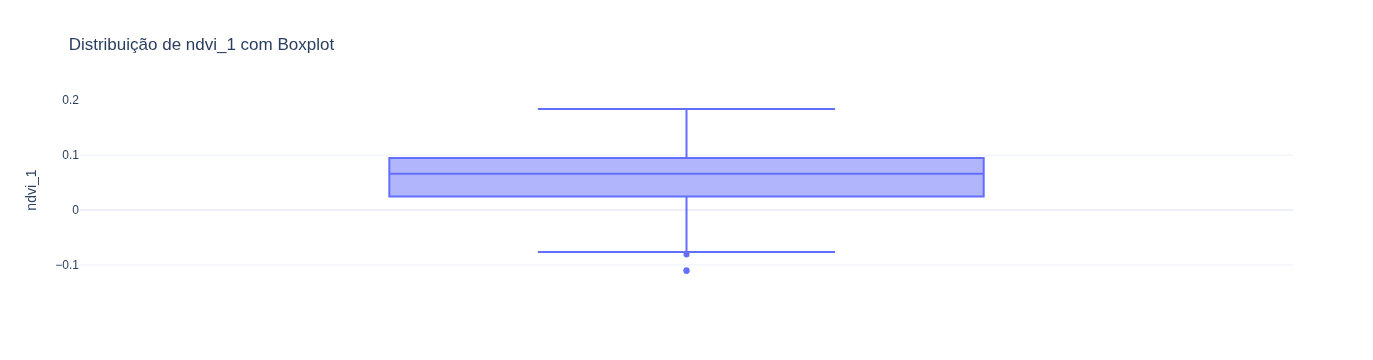

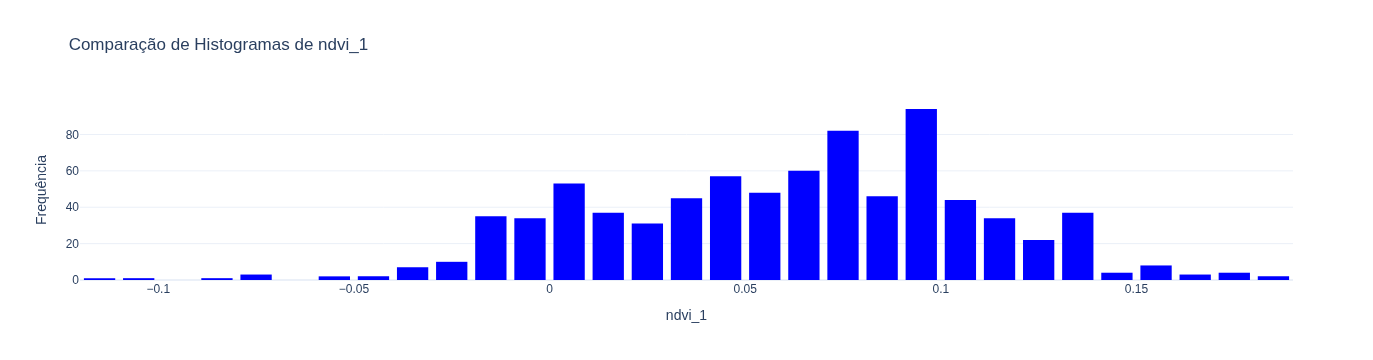




 ----- Análise do índice NBR a partir dos focos -----
Mediana: 0.1549
Q1 (1º Quartil): 0.0939
(Mediana + Q1) / 2: 0.1244
Desvio Padrão: 0.0854
Mínimo: -0.0536
Máximo: 0.3797


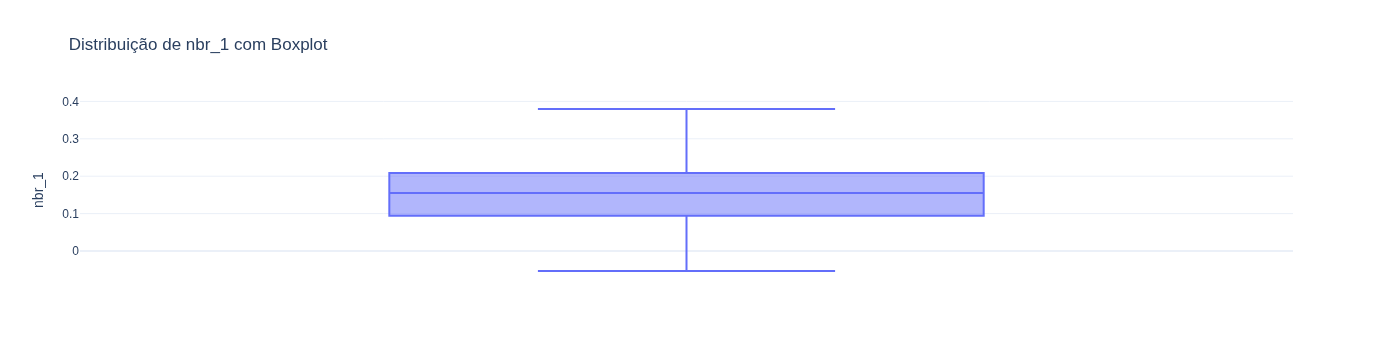

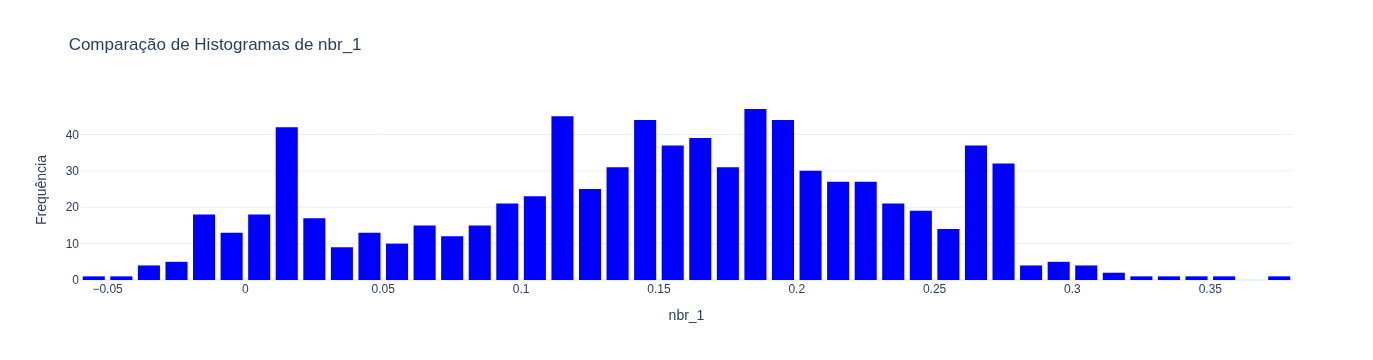




 ----- Análise do índice NBRSWIR -----
Mediana: 0.0801
Q1 (1º Quartil): 0.0503
(Mediana + Q1) / 2: 0.0652
Desvio Padrão: 0.0426
Mínimo: -0.0193
Máximo: 0.1906


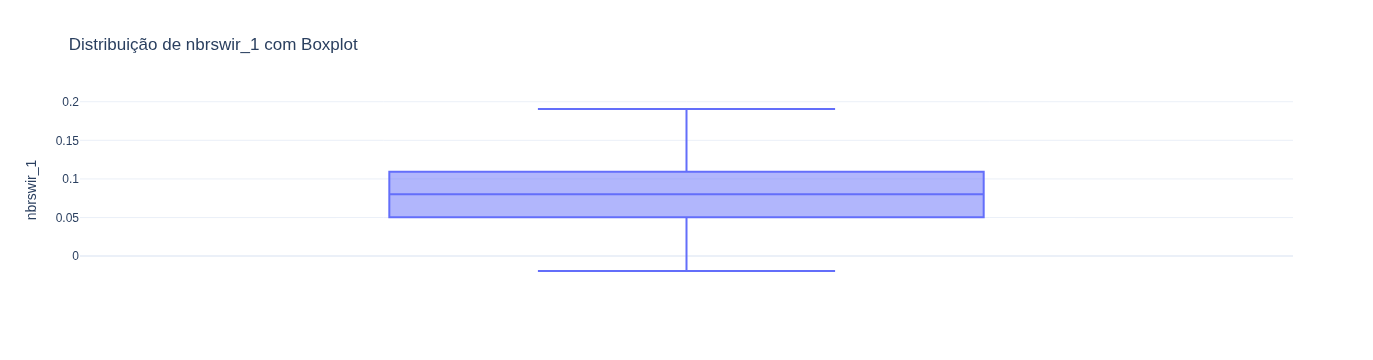

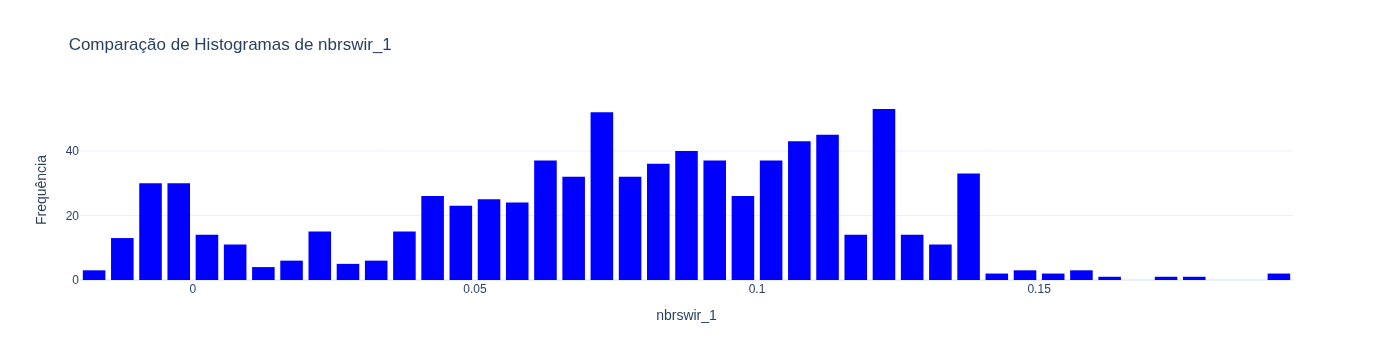

In [9]:
# --- Teste utilizando dados extraidos a partir da área queimada
# print(f"\n\n\n ----- Análise do índice NDVI -----")
# analise_exploratoria(gdf_ndvi, 'ndvi')
# histograma_comparativo(gdf_ndvi, 'ndvi')

# print(f"\n\n\n ----- Análise do índice NBR -----")
# analise_exploratoria(gdf_nbr, 'nbr')
# histograma_comparativo(gdf_nbr, 'nbr')

# print(f"\n\n\n ----- Análise do índice NBRSWIR -----")
# analise_exploratoria(gdf_nbrswir, 'nbrswir')
# histograma_comparativo(gdf_nbrswir, 'nbrswir')


# --- Teste usando os focos como referencia
print(f"\n\n\n ----- Análise do índice NDVI a partir dos focos -----")
analise_exploratoria(gdf_focos_indices, 'ndvi_1')
histograma_comparativo(gdf_focos_indices, 'ndvi_1')

print(f"\n\n\n ----- Análise do índice NBR a partir dos focos -----")
analise_exploratoria(gdf_focos_indices, 'nbr_1')
histograma_comparativo(gdf_focos_indices, 'nbr_1')

print(f"\n\n\n ----- Análise do índice NBRSWIR -----")
analise_exploratoria(gdf_focos_indices, 'nbrswir_1')
histograma_comparativo(gdf_focos_indices, 'nbrswir_1')

# --- Teste com todos os dados do .tif (muitas amostras contamiandas)
# print(f"\n\n\n ----- Análise do índice NDVI -----")
# analise_exploratoria(gdf_full_ndvi, 'ndvi')
# histograma_comparativo(gdf_full_ndvi, 'ndvi')

# print(f"\n\n\n ----- Análise do índice NBR -----")
# analise_exploratoria(gdf_full_nbr, 'nbr')
# histograma_comparativo(gdf_full_nbr, 'nbr')

# print(f"\n\n\n ----- Análise do índice NBRSWIR -----")
# analise_exploratoria(gdf_full_nbrswir, 'nbrswir')
# histograma_comparativo(gdf_full_nbrswir, 'nbrswir')
